In [ ]:
# Cell 1: Synthetic Data & Preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Generate a synthetic stock trend (Sine wave + random noise)
t = np.linspace(0, 100, 1000)
stock_data = np.sin(t) + np.random.normal(0, 0.1, 1000)
data = stock_data.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences (Windowing)
def create_sequences(dataset, window=60):
    X, y = [], []
    for i in range(window, len(dataset)):
        X.append(dataset[i-window:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
# Reshape for LSTM [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("Data prepared. Shape:", X.shape)
# why it shows invalid haa

Data prepared. Shape: (940, 60, 1)


In [2]:
# Cell 2: Build the LSTM Model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1) # Predicting a single continuous value
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

e:\dllabs\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Cell 3: Train the Model
history = model.fit(X, y, batch_size=32, epochs=10, verbose=1)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0755
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0138
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0056
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0054
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0043
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0040
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0042
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0038
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0041
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0039


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


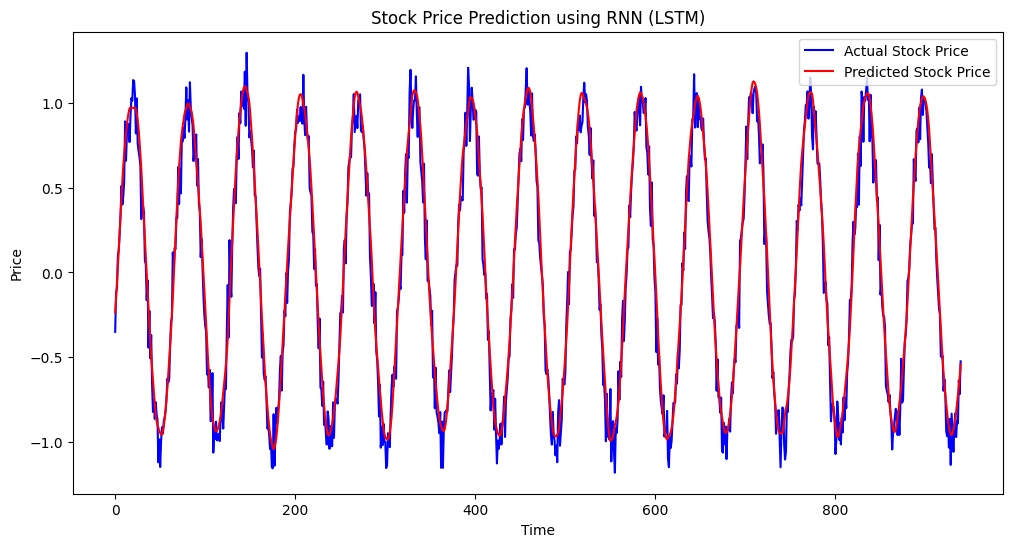

In [4]:
# Cell 4: Predict and Plot
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(actual, color='blue', label='Actual Stock Price')
plt.plot(predictions, color='red', label='Predicted Stock Price')
plt.title('Stock Price Prediction using RNN (LSTM)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()